## Zonal Stats for the Voronoi Cells

In this notebook, we are trying to get the zonal stats for the voronoi cells spatial units that are available for the CDR data. 

This is an attempt to homogenize the datasets and bring them to the same scale. This is a zonal statistical approach that will be replaced by the DGGS approach to use hierarchical grid systems to avoid the data conversion. 

In [4]:
## import libraries
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
import re
import time
from datetime import datetime
import scipy
from tqdm import tqdm
from dask import delayed, compute
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

import logging

# import xesmf as xe
import xvec
import ujson
import fsspec
from kerchunk.hdf import SingleHdf5ToZarr
from kerchunk.combine import MultiZarrToZarr

from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import lexcube 
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

import warnings
warnings.filterwarnings("ignore")
from read_check import*

## Check data and dimensions

In [12]:
# from read_check import check, read, plot

# # Specify the data path directly instead of using input()
# data_path = "/home/kzakir/dvcube/test/data/test_data/testdata1"
# dataset, netcdf_file = read(data_path)
# print(dataset.dims)
# print(dataset.coords)
# print(dataset.data_vars)

# # Then plot a specific variable
# plot(dataset, "METREF")

Opening NetCDF file: /home/kzakir/dvcube/test/data/test_data/testdata1/01/01/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001010000.nc
FrozenMappingWarningOnValuesAccess({'time': 1, 'lat': 3201, 'lon': 3201})
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float32 13kB 80.0 79.95 79.9 79.85 ... -79.9 -79.95 -80.0
  * lon      (lon) float32 13kB -80.0 -79.95 -79.9 -79.85 ... 79.9 79.95 80.0
Data variables:
    METREF        (time, lat, lon) float64 82MB ...
    crs           |S1 1B ...
    quality_flag  (time, lat, lon) float64 82MB ...


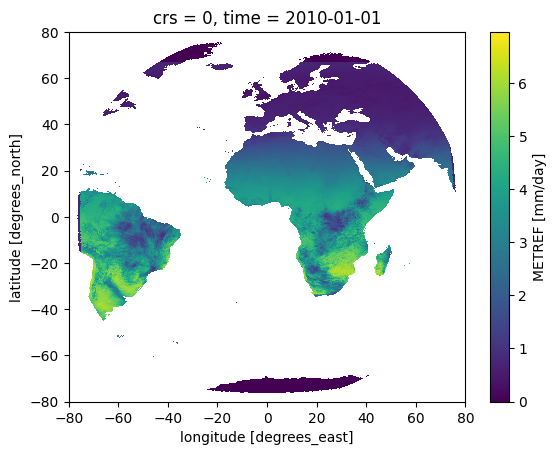

In [10]:
%run /home/kzakir/dvcube/test/cube_example/read_check.py

## Create 1 Kerchunk per file

In [16]:
data_path = Path("/home/kzakir/dvcube/test/data/test_data/testdata1")
out_dir = Path("/home/kzakir/dvcube/test/data/test_data/testdata1/kerchunk_refs/single")

out_dir.mkdir(parents=True, exist_ok=True)

nc_files = sorted(data_path.rglob("*.nc"))
print(f"Found {len(nc_files)} NetCDF files.")

def make_safe_name(path:Path) -> str:
    """Create a safe name for the output JSON file based on the input NetCDF file path."""
    return re.sub(r'[^a-zA-Z0-9]', '_', str(path.relative_to(data_path))) + ".json"

def make_single_ref(nc_path:Path, out_dir:Path) -> Path:
    """Create a single reference JSON file for a given NetCDF file."""
    out_json = out_dir / make_safe_name(nc_path)
    target_url = nc_path.as_uri()  # Convert the path to a file URI

    with fsspec.open(target_url, mode='rb') as f:
        h5chunks = SingleHdf5ToZarr(f, target_url, inline_threshold=300)
        refs = h5chunks.translate()
    with open(out_json, 'w') as f:
        ujson.dump(refs, f)
    return out_json
for i, nc_file in enumerate(nc_files, start=1):
    print(f"Processing file {i}/{len(nc_files)}: {nc_file}")
    make_single_ref(nc_file, out_dir)

print(f"Single reference JSON files created in {out_dir}.")


Found 151 NetCDF files.
Processing file 1/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/01/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001010000.nc
Processing file 2/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/02/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001020000.nc
Processing file 3/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/03/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001030000.nc
Processing file 4/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/04/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001040000.nc
Processing file 5/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/05/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001050000.nc
Processing file 6/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/06/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001060000.nc
Processing file 7/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/07/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001070000.nc
Processing file 8/151: /home/kzakir/dvcube/test/data/test_data/tes

In [21]:
import nest_asyncio
nest_asyncio.apply()

In [27]:
single_json_files = Path("/home/kzakir/dvcube/test/data/test_data/testdata1/kerchunk_refs/single")
out_dir_multi = Path("/home/kzakir/dvcube/test/data/test_data/testdata1/kerchunk_refs/combined")
out_dir_multi.mkdir(parents=True, exist_ok=True)

json_files = sorted(single_json_files.rglob("*.json"))
print(f"Found {len(json_files)} single reference JSON files.")

mzz = MultiZarrToZarr(
    path=[str(f) for f in json_files],
    remote_protocol="file",
    concat_dims=["time"],
    inline_threshold=0,
    coo_map={"time": "cf:time"},
    identical_dims=["lat", "lon"],)

combined_refs = mzz.translate()
out_json_multi = out_dir_multi / "combined_refs.json"
with open(out_json_multi, 'w') as f:
    ujson.dump(combined_refs, f)
print(f"Combined reference JSON file created at {out_json_multi}.")

Found 151 single reference JSON files.
Combined reference JSON file created at /home/kzakir/dvcube/test/data/test_data/testdata1/kerchunk_refs/combined/combined_refs.json.


In [97]:
ref_json = out_json_multi
ds = xr.open_dataset(
    "reference://",
    engine="zarr",
    backend_kwargs={"consolidated": False,
                     "storage_options": {"fo": str(ref_json),
                                         "remote_protocol": "file"},
    },
                                                                         
)

ds

<xarray.Dataset> Size: 25GB
Dimensions:       (time: 151, lat: 3201, lon: 3201)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2010-01-01 2010-01-02 ... 2010-05-31
  * lat           (lat) float32 13kB 80.0 79.95 79.9 ... -79.9 -79.95 -80.0
  * lon           (lon) float32 13kB -80.0 -79.95 -79.9 ... 79.9 79.95 80.0
Data variables:
    METREF        (time, lat, lon) float64 12GB ...
    quality_flag  (time, lat, lon) float64 12GB ...
    crs           (time) object 1kB ...
Attributes: (12/27)
    Conventions:                CF-1.6
    algorithm_version:          1.3.2
    archive_facility:           IPMA
    base_algorithm_version:     1.0.3
    date_created:               2020-11-09T17:30:27Z
    easternmost_longitude:      -80.0
    ...                         ...
    region_name:                MSG-Disk
    sensor:                     SEVI
    southernmost_latitude:      -80.0
    spatial_resolution:          0.05x 0.05
    time_coverage_start:        2010-01-01T00:00:00Z
    westernmost_longitude:      80.0

In [98]:
if "crs" in ds.data_vars:
    ds = ds.drop_vars("crs")
ds = ds.isel(
    lat = np.where(np.isfinite(ds['lat'].values))[0],
    lon = np.where(np.isfinite(ds['lon'].values))[0]
)

ds = ds.sortby('lat')
ds = ds.sortby('lon')
print(ds.lat.values[:5], ds.lat.values[-5:], ds.lon.values[:5], ds.lon.values[-5:])



[-80.   -79.95 -79.9  -79.85 -79.8 ] [79.8      79.850006 79.90001  79.95     80.      ] [-80.   -79.95 -79.9  -79.85 -79.8 ] [79.8      79.850006 79.90001  79.95     80.      ]


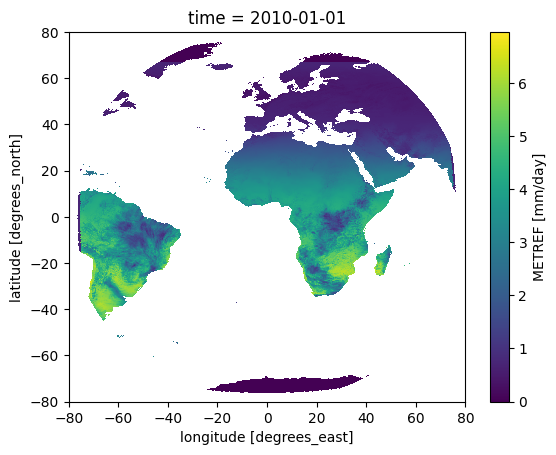

In [100]:
ds["METREF"].isel(time=0).plot()    

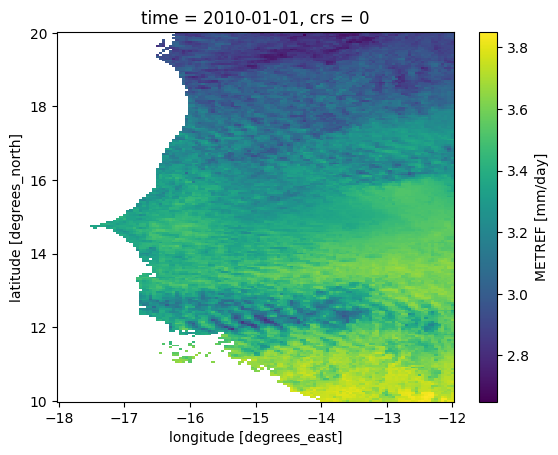

In [107]:
sahel_bbox = {
    "lon_min": -18,
    "lon_max": -12,
    "lat_min": 10,
    "lat_max": 20
}

ds_sahel = ds.sel(
    lon=slice(sahel_bbox["lon_min"], sahel_bbox["lon_max"]),
    lat=slice(sahel_bbox["lat_min"], sahel_bbox["lat_max"])
)
ds_sahel = ds_sahel.rio.write_crs("EPSG:4326", inplace=False)
ds_sahel["METREF"].isel(time=0).plot()

In [108]:
# load the spatial units

units = gpd.read_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units_with_lat_lon.parquet")
units

,id,name,zone_category,geometry,norm_id,lon,lat
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",sen.1.1.1,-17.187838,14.751204
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",sen.10.1.1,-15.585999,16.227448
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",sen.10.1.2,-16.093441,16.263351
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",sen.10.2.1,-14.229220,16.239571
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",sen.10.2.2,-14.684249,16.288648
...,...,...,...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",city-048,-16.926520,14.790789
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",city-049,-16.812656,14.965186
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",city-050,-15.871611,14.854303
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",city-052,-14.122209,13.141354


In [109]:
aggregated = ds_sahel.METREF.xvec.zonal_stats(
    units.geometry, x_coords= "lon", y_coords="lat", 
    # stats = "mean",
    method="exactextract"
)
aggregated

<xarray.DataArray (geometry: 151, time: 151)> Size: 182kB
array([[3.35369473, 3.41783503, 2.9734863 , ..., 5.26858478, 5.28593862,
        5.08179411],
       [3.25383115, 3.47967237, 3.35512076, ..., 5.90076381, 5.8744769 ,
        5.11931756],
       [3.28446945, 3.44706852, 3.22372583, ..., 5.79078642, 5.81121989,
        5.4314872 ],
       ...,
       [3.43664193, 3.53029977, 3.10314345, ..., 5.56636911, 5.25124548,
        5.29753852],
       [3.48780924, 3.61533559, 3.45140253, ..., 5.11581189, 4.34356965,
        4.01901608],
       [3.15907804, 3.58363045, 3.45239147, ..., 4.76475703, 3.75525724,
        4.53680109]], shape=(151, 151))
Coordinates:
  * geometry  (geometry) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377...
  * time      (time) datetime64[ns] 1kB 2010-01-01 2010-01-02 ... 2010-05-31
Indexes:
    geometry  GeometryIndex (crs=EPSG:4326)
Attributes:
    long_name:  METREF
    units:      mm/day
    valid_min:  0

In [110]:
print(aggregated.dims)

('geometry', 'time')


(<Figure size 900x438.187 with 13 Axes>,
 array([[<Axes: title={'center': 'time = 2010-01-01'}, ylabel='Geodetic latitude\n[degree]'>,
         <Axes: title={'center': 'time = 2010-01-02'}>,
         <Axes: title={'center': 'time = 2010-01-03'}>],
        [<Axes: title={'center': 'time = 2010-01-04'}, xlabel='Geodetic longitude\n[degree]', ylabel='Geodetic latitude\n[degree]'>,
         <Axes: title={'center': 'time = 2010-01-05'}, xlabel='Geodetic longitude\n[degree]'>,
         <Axes: title={'center': 'time = 2010-01-06'}, xlabel='Geodetic longitude\n[degree]'>]],
       dtype=object))

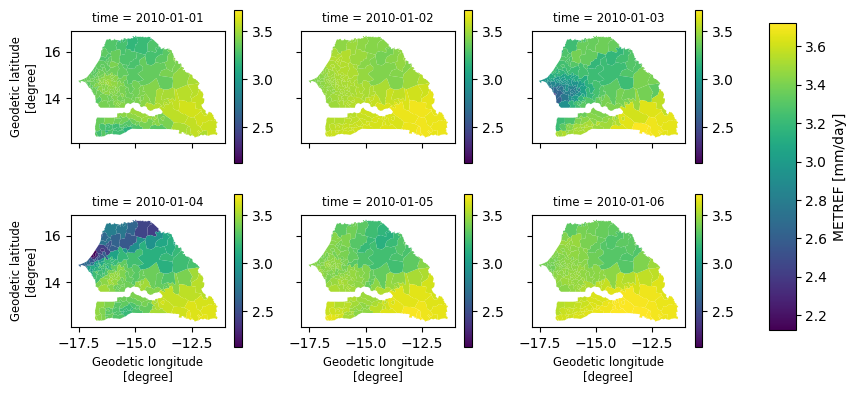

In [114]:
aggregated.isel(time=slice(0, 6)).xvec.plot(
    col="time",
    col_wrap=3,
    cmap="viridis",
    legend=True,
)